# Final Assignment :Non Preemptive Schedule Search

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import itertools, math


## 1 : t1 Execution-Time Statistics

t₁ Execution time statistics
  Min           : 0.001200 s
  Q1 (25%)      : 0.001219 s
  Q2 (Median)   : 0.001230 s
  Q3 (75%)      : 0.001266 s
  Max (WCET)    : 0.004712 s


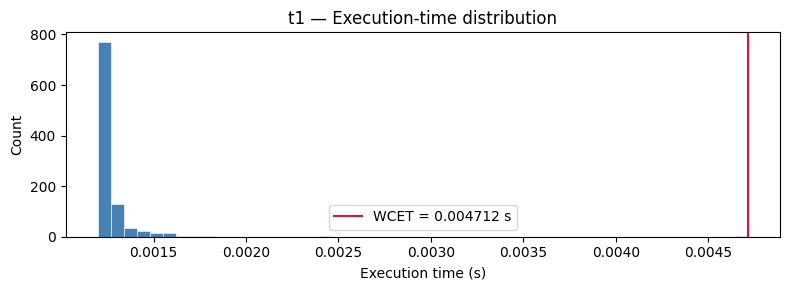

In [ ]:
times = pd.read_csv('execution_times.csv', header=None, names=['t'])['t'].values

stats = {
    'Min'        : np.min(times),
    'Q1 (25%)'   : np.percentile(times, 25),
    'Q2 (Median)': np.percentile(times, 50),
    'Q3 (75%)'   : np.percentile(times, 75),
    'Max (WCET)' : np.max(times),
}
C1 = stats['Max (WCET)']

print("t₁ Execution time statistics")
for k, v in stats.items():
    print(f"  {k:<14}: {v:.6f} s")

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(times, bins=50, color='steelblue', edgecolor='white', linewidth=0.4)
ax.axvline(C1, color='crimson', linewidth=1.5, label=f'WCET = {C1:.6f} s')
ax.set(xlabel='Execution time (s)', ylabel='Count', title='t1 — Execution-time distribution')
ax.legend()
plt.tight_layout()
plt.show()

## 2 : Task Set

| Task | C (s) | T (period) | D (deadline) |
|------|-------------------|------------|------------------|
| τ₁   | C₁ = 0.0047 s     | 10         | 10               |
| τ₂   | 3                 | 10         | 10               |
| τ₃   | 2                 | 20         | 20               |
| τ₄   | 2                 | 20         | 20               |
| τ₅   | 2                 | 40         | 40               |
| τ₆   | 2                 | 40         | 40               |
| τ₇   | 3                 | 80         | 80               |

In [35]:
TASKS = [
    {'id': 't1', 'C': C1, 'T': 10},
    {'id': 't2', 'C': 3,  'T': 10},
    {'id': 't3', 'C': 2,  'T': 20},
    {'id': 't4', 'C': 2,  'T': 20},
    {'id': 't5', 'C': 2,  'T': 40},
    {'id': 't6', 'C': 2,  'T': 40},
    {'id': 't7', 'C': 3,  'T': 80},
]
N = len(TASKS)
H = 80   # hyperperiod

print(f"{'Task':<5} {'C':>10} {'T':>5} {'D':>5}")
print("-" * 25)
for t in TASKS:
    print(f"{t['id']:<5} {t['C']:>10.6f} {t['T']:>5} {t['T']:>5}")

Task           C     T     D
-------------------------
t1      0.004712    10    10
t2      3.000000    10    10
t3      2.000000    20    20
t4      2.000000    20    20
t5      2.000000    40    40
t6      2.000000    40    40
t7      3.000000    80    80


## 3 : Schedulability Check

A necessary condition for a set of periodic tasks to be schedulable is:

$$U = \sum_{i=1}^{n} \frac{C_i}{T_i} \leq 1$$

In [36]:
U = sum(t['C'] / t['T'] for t in TASKS)
print(f"Processor utilisation  U = {U:.6f}")
print(f"Idle-time budget       H·(1−U) = {H*(1-U):.4f} time units")
print()
if U <= 1:
    print("U ≤ 1  →  Task set is schedulable.")
else:
    print("U > 1  →  Task set is not schedulable.")

Processor utilisation  U = 0.637971
Idle-time budget       H·(1−U) = 28.9623 time units

U ≤ 1  →  Task set is schedulable.


## 4 : Non-Preemptive Schedule Search

In [37]:
def simulate(priority_order, horizon=H, allow_t5_miss=False):

    jobs = [
        {'id': t['id'], 'prio': i, 'arr': float(arr),
         'dl': float(arr + t['T']), 'C': t['C'], 'done': False}
        for i, t in enumerate(priority_order)
        for arr in np.arange(0, horizon, t['T'])
    ]

    curr_t, total_wait, t5_misses, schedule = 0.0, 0.0, 0, []

    while any(not j['done'] for j in jobs):
        ready = [j for j in jobs if j['arr'] <= curr_t and not j['done']]
        if not ready:
            curr_t = min(j['arr'] for j in jobs if not j['done'])
            continue

        curr = min(ready, key=lambda x: x['prio'])
        total_wait += curr_t - curr['arr']
        start   = curr_t
        curr_t += curr['C']
        curr['done'] = True

        if curr_t > curr['dl']:
            if allow_t5_miss and curr['id'] == 'τ5':
                t5_misses += 1
            else:
                return None, float('inf'), 0

        schedule.append((curr['id'], start, curr_t, curr['dl']))

    return schedule, total_wait, t5_misses

In [38]:
best_schedule, best_order, min_wait = None, None, float('inf')
valid_count = 0
total_perms = math.factorial(N)

for perm in itertools.permutations(TASKS):
    s, w, _ = simulate(perm)
    if s:
        valid_count += 1
        if w < min_wait:
            min_wait, best_schedule, best_order = w, s, [t['id'] for t in perm]

print(f"Valid schedules : {valid_count} / {total_perms}")
print(f"Optimal order   : {' > '.join(best_order)}")
print(f"Min total wait  : {min_wait:.4f} time units")

Valid schedules : 1824 / 5040
Optimal order   : t1 > t3 > t4 > t5 > t2 > t6 > t7
Min total wait  : 72.1225 time units


## 5 : Response-Time Analysis

For each job in the optimal schedule we compute:

$$R_i = \text{finish}_i - \text{arrival}_i \qquad \text{(response time)}$$

Schedulability requires $R_i \leq D_i = T_i$ for every job.

In [39]:
# Build a lookup: task_id → period
period = {t['id']: t['T'] for t in TASKS}

# Compute arrival from schedule entry (start - wait, but we need arrival directly)
# Re-run to collect per-job arrival information
best_perm = next(
    perm for perm in itertools.permutations(TASKS)
    if [t['id'] for t in perm] == best_order
)

# Rebuild jobs with arrival info
jobs_detail = [
    {'id': t['id'], 'prio': i, 'arr': float(arr),
     'dl': float(arr + t['T']), 'C': t['C'], 'done': False}
    for i, t in enumerate(best_perm)
    for arr in np.arange(0, H, t['T'])
]

# Match schedule entries to jobs by task_id and chronological order
from collections import defaultdict
counters = defaultdict(int)
sorted_jobs = {tid: sorted([j for j in jobs_detail if j['id'] == tid], key=lambda x: x['arr'])
               for tid in period}

rows = []
for (tid, start, finish, dl) in sorted(best_schedule, key=lambda x: x[1]):
    idx   = counters[tid]; counters[tid] += 1
    arr   = sorted_jobs[tid][idx]['arr']
    R     = finish - arr
    D     = period[tid]
    rows.append({'Job': f"{tid}[{idx}]", 'Arrival': arr, 'Start': start,
                 'Finish': finish, 'Deadline': dl, 'R': R, 'D': D,
                 'R≤D': 'ok' if R <= D + 1e-9 else 'no'})

df_rt = pd.DataFrame(rows)
print(df_rt.to_string(index=False, float_format='{:.4f}'.format))
print()
missed = (df_rt['R≤D'] == 'no').sum()
print(f"Missed deadlines : {missed}  {'→ All deadlines met' if missed == 0 else '→ one or even more deadlines missed'}")

  Job  Arrival   Start  Finish  Deadline       R  D R≤D
t1[0]   0.0000  0.0000  0.0047   10.0000  0.0047 10  ok
t3[0]   0.0000  0.0047  2.0047   20.0000  2.0047 20  ok
t4[0]   0.0000  2.0047  4.0047   20.0000  4.0047 20  ok
t5[0]   0.0000  4.0047  6.0047   40.0000  6.0047 40  ok
t2[0]   0.0000  6.0047  9.0047   10.0000  9.0047 10  ok
t6[0]   0.0000  9.0047 11.0047   40.0000 11.0047 40  ok
t1[1]  10.0000 11.0047 11.0094   20.0000  1.0094 10  ok
t2[1]  10.0000 11.0094 14.0094   20.0000  4.0094 10  ok
t7[0]   0.0000 14.0094 17.0094   80.0000 17.0094 80  ok
t1[2]  20.0000 20.0000 20.0047   30.0000  0.0047 10  ok
t3[1]  20.0000 20.0047 22.0047   40.0000  2.0047 20  ok
t4[1]  20.0000 22.0047 24.0047   40.0000  4.0047 20  ok
t2[2]  20.0000 24.0047 27.0047   30.0000  7.0047 10  ok
t1[3]  30.0000 30.0000 30.0047   40.0000  0.0047 10  ok
t2[3]  30.0000 30.0047 33.0047   40.0000  3.0047 10  ok
t1[4]  40.0000 40.0000 40.0047   50.0000  0.0047 10  ok
t3[2]  40.0000 40.0047 42.0047   60.0000  2.0047

## 6 : Processor Idle Time

The idle time is determined solely by the utilisation:

$$I = H \cdot (1 - U)$$

In [40]:
def idle_time(schedule, horizon=H):
    """Total processor idle time over [0, horizon]."""
    curr = 0.0
    idle = 0.0
    for _, start, finish, _ in sorted(schedule, key=lambda x: x[1]):
        if start > curr:
            idle += start - curr
        curr = max(curr, finish)
    if curr < horizon:
        idle += horizon - curr
    return idle

theoretical_idle = H * (1 - U)
best_idle = idle_time(best_schedule)

# Check a second valid (non-optimal) schedule
other_idle = None
for perm in itertools.permutations(TASKS):
    s, w, _ = simulate(perm)
    if s and abs(w - min_wait) > 1e-6:
        other_idle = idle_time(s)
        break

print(f"Theoretical idle time  H·(1−U)        = {theoretical_idle:.4f}")
print(f"Optimal schedule idle time             = {best_idle:.4f}")
print(f"Alternative valid schedule idle time   = {other_idle:.4f}")
print()
print("→ Idle time is CONSTANT across all valid schedules.")
print("  Minimising total waiting time does not imply maximising idle time;")
print("  idle time equals H·(1−U) regardless of the priority order chosen.")

Theoretical idle time  H·(1−U)        = 28.9623
Optimal schedule idle time             = 28.9623
Alternative valid schedule idle time   = 28.9623

→ Idle time is CONSTANT across all valid schedules.
  Minimising total waiting time does not imply maximising idle time;
  idle time equals H·(1−U) regardless of the priority order chosen.


## 7 : Schedule with t₅ Allowed to Miss Its Deadline

In [41]:
best_s5, best_p5, min_w5 = None, None, float('inf')
count5 = 0
best_misses5 = 0

for perm in itertools.permutations(TASKS):
    s, w, m = simulate(perm, allow_t5_miss=True)
    if s:
        count5 += 1
        if w < min_w5:
            min_w5, best_s5, best_p5, best_misses5 = w, s, [t['id'] for t in perm], m

print(f"Valid schedules                : {count5} / {total_perms}")
print(f"Optimal order                  : {' > '.join(best_p5)}")
print(f"Min total wait                 : {min_w5:.4f}")
print(f"t5 deadline misses             : {best_misses5}")
print(f"Idle time                      : {idle_time(best_s5):.4f}")

Valid schedules                : 1824 / 5040
Optimal order                  : t1 > t3 > t4 > t5 > t2 > t6 > t7
Min total wait                 : 72.1225
t5 deadline misses             : 0
Idle time                      : 28.9623


## 8 : Gantt Chart

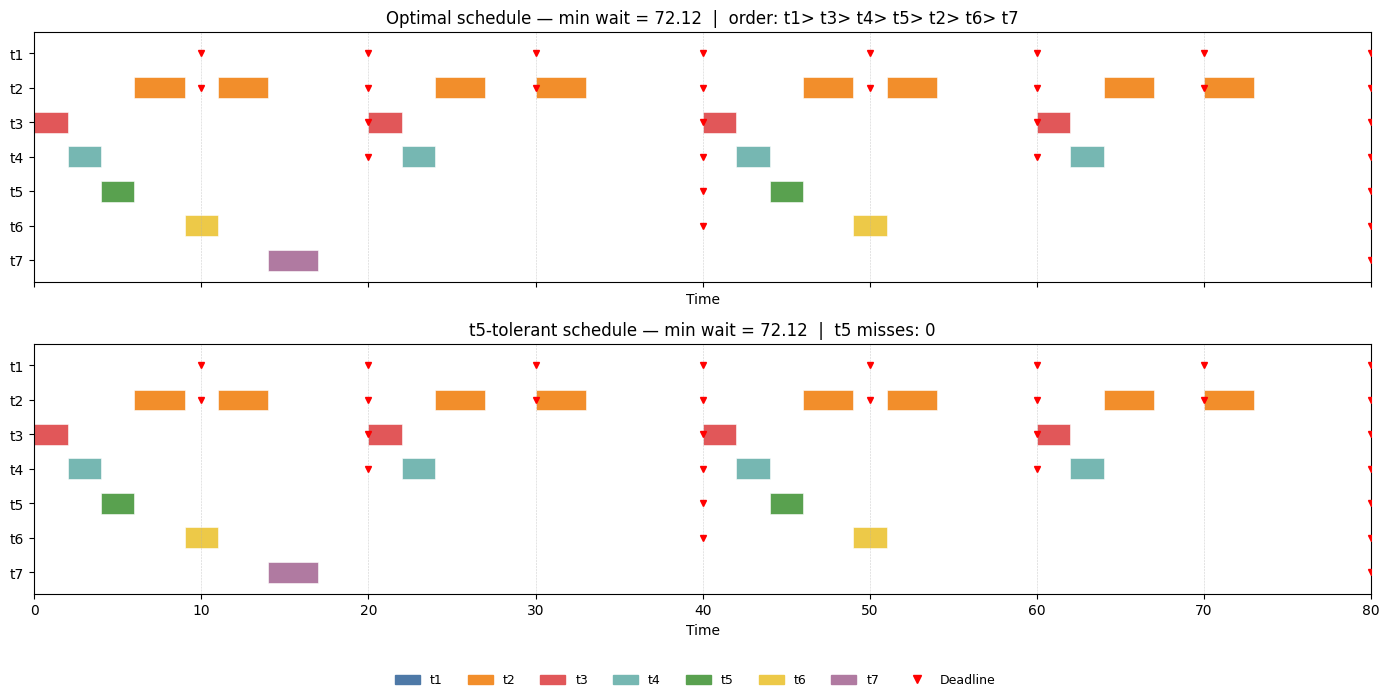

In [ ]:
COLORS = {
    't1': '#4e79a7', 't2': '#f28e2b', 't3': '#e15759',
    't4': '#76b7b2', 't5': '#59a14f', 't6': '#edc948', 't7': '#b07aa1'
}

def gantt(schedule, title, ax):
    task_ids = list(COLORS.keys())
    y_pos    = {tid: i for i, tid in enumerate(task_ids)}

    for tid, start, finish, dl in schedule:
        y = y_pos[tid]
        ax.barh(y, finish - start, left=start, height=0.6,
                color=COLORS[tid], edgecolor='white', linewidth=0.4)
        ax.plot(dl, y, 'v', color='red', markersize=5, zorder=5)

    ax.set_yticks(range(len(task_ids)))
    ax.set_yticklabels(task_ids)
    ax.set_xlim(0, H)
    ax.set_xlabel('Time')
    ax.set_title(title)
    ax.grid(axis='x', linestyle='--', linewidth=0.4, alpha=0.6)
    ax.invert_yaxis()

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

gantt(best_schedule, f'Optimal schedule — min wait = {min_wait:.2f}  |  order: {"> ".join(best_order)}', axes[0])
gantt(best_s5,       f't5-tolerant schedule — min wait = {min_w5:.2f}  |  t5 misses: {best_misses5}', axes[1])

legend = [mpatches.Patch(color=c, label=t) for t, c in COLORS.items()]
legend.append(plt.Line2D([0],[0], marker='v', color='red', linestyle='None', markersize=6, label='Deadline'))
fig.legend(handles=legend, loc='lower center', ncol=8, frameon=False, fontsize=9)

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

We notice that t1 does not appear, but in reality it does. It’s only because it has a very small value compared to other execution times, so we don’t see it; that’s why, moreover, with or without the deadline miss of t5 being authorized, the gantt chart doesn’t change.